# Symmetry Groups and Cayley Graphs
## Building ℤₙ, Dₙ, and Q₈ from scratch, and seeing their shapes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/courses/blob/main/2026fall/mat4233/downloads/public/activities/cayley-graphs-symmetry-groups.ipynb)
[![License: CC BY 4.0](https://img.shields.io/badge/License-CC%20BY%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by/4.0/)

---

This notebook builds three small but genuinely different finite groups from
scratch, in code, and lets their **Cayley graphs** — one node per element,
one edge per generator — show structure that a bare definition doesn't:

1. **The cyclic group ℤₙ** — the baseline: one generator, one loop.
2. **The dihedral group Dₙ**, the symmetries of a regular $n$-gon, built as
   maps of the complex plane — non-abelian, and visibly so once it's drawn.
3. **A same-size comparison** — ℤ₈ and D4 both have 8 elements; their Cayley
   graphs make it obvious that "8 elements" doesn't mean "one kind of group."
4. **The quaternion group Q8** (optional) — a second non-abelian group of
   order 8, genuinely different from D4 despite matching it in size.

There's nothing to submit here and no grade attached, and no single correct
final answer to reach. It's meant to be tinkered with: change a number,
rerun, see what breaks. Feel free to stop and pick it back up later — nothing
depends on finishing in one sitting, only on running Section 1 before
Section 2. *Runtime → Run all* always gets you back to a clean state.


---
# 0. Setup

This notebook runs equally well on **Google Colab** and in a **local Jupyter
installation** — no GPU needed.

- **Colab**: click *Open in Colab* above; the cell below will just work.
- **Local**: `pip install matplotlib networkx numpy`, then open this file
  with `jupyter notebook` or `jupyter lab`.


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import cmath


---
# 1. A cyclic group: ℤₙ

Before running anything: if you draw an arrow from every number `a` to
`a + 1` (mod `n`), what shape do you expect the picture to make?


In [2]:
def cyclic_cayley_table(n):
    return [[(a + b) % n for b in range(n)] for a in range(n)]

def cyclic_cayley_graph(n, gen=1):
    """Directed graph: one arrow a -> a+gen (mod n) per element."""
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for a in range(n):
        G.add_edge(a, (a + gen) % n)
    return G, nx.circular_layout(G)

n = 6
for row in cyclic_cayley_table(n):
    print(row)


[0, 1, 2, 3, 4, 5]
[1, 2, 3, 4, 5, 0]
[2, 3, 4, 5, 0, 1]
[3, 4, 5, 0, 1, 2]
[4, 5, 0, 1, 2, 3]
[5, 0, 1, 2, 3, 4]


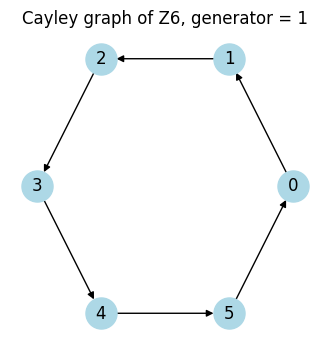

In [3]:
G, pos = cyclic_cayley_graph(n, gen=1)
fig, ax = plt.subplots(figsize=(4, 4))
nx.draw(G, pos, with_labels=True, node_color="lightblue", ax=ax, arrows=True, node_size=500)
ax.set_title(f"Cayley graph of Z{n}, generator = 1")
plt.show()


**Try it:** change `n` to 8, then to 5, then to 12, and rerun both cells
above. Does the *shape* ever change? Why must a cyclic group generated by a
single element always look this way, no matter how large it is?


---
# 2. The symmetries of a regular polygon: Dₙ

The symmetries of a square — 4 rotations and 4 reflections — form one of the
standard first examples of a non-abelian group, and the construction extends
to any regular $n$-gon: the dihedral group $D_n$, of order $2n$. We build
these symmetries directly as maps of the complex plane, and let the computer
work out the group table for us — no table copied from a book required.

Each symmetry is either $z \mapsto \zeta^k z$ (a rotation by $k$ turns of
$2\pi/n$, $\zeta = e^{2\pi i/n}$) or $z \mapsto \zeta^k \bar z$ (a
reflection). To find what two symmetries compose to, we apply both to one
*generic* point and see which of the $2n$ known maps lands on the same spot.


In [4]:
def dihedral_elements(n):
    return [(k, 0) for k in range(n)] + [(k, 1) for k in range(n)]

def dihedral_names(n):
    rot = ["e"] + [(f"r{k}" if k > 1 else "r") for k in range(1, n)]
    ref = ["s"] + [(f"r{k}s" if k > 1 else "rs") for k in range(1, n)]
    return rot + ref

def make_dihedral_group(n):
    """D_n as isometries of the plane: rotations z -> zeta^k z and
    reflections z -> zeta^k * conjugate(z), zeta = exp(2 pi i / n)."""
    elts = dihedral_elements(n)
    names = dihedral_names(n)
    name_of = dict(zip(elts, names))
    z0 = 2 + 1j  # a point on no axis of symmetry, so every image is distinct

    def apply(elt, z):
        k, flip = elt
        w = cmath.exp(2j * cmath.pi * k / n) * z
        return w.conjugate() if flip else w

    vals = {e: apply(e, z0) for e in elts}

    def compose(e1, e2):
        """The single element equal to: do e1 first, then e2."""
        target = apply(e2, apply(e1, z0))
        best = min(elts, key=lambda c: abs(vals[c] - target))
        assert abs(vals[best] - target) < 1e-9
        return best

    return elts, names, name_of, compose

elts, names, name_of, compose = make_dihedral_group(4)
r, s = (1, 0), (0, 1)   # a quarter-turn, and one fixed reflection
print("r then s ->", name_of[compose(r, s)])
print("s then r ->", name_of[compose(s, r)])


r then s -> rs
s then r -> r3s


**Before running the next cell:** based on the two lines above, is D4
abelian? What would it mean, physically, for "rotate then reflect" and
"reflect then rotate" to land on the same symmetry?


In [5]:
print("        " + "  ".join(f"{nm:>4}" for nm in names))
for e1 in elts:
    row = [name_of[compose(e1, e2)] for e2 in elts]
    print(f"{name_of[e1]:>6}  " + "  ".join(f"{v:>4}" for v in row))


           e     r    r2    r3     s    rs   r2s   r3s
     e     e     r    r2    r3     s    rs   r2s   r3s
     r     r    r2    r3     e    rs   r2s   r3s     s
    r2    r2    r3     e     r   r2s   r3s     s    rs
    r3    r3     e     r    r2   r3s     s    rs   r2s
     s     s   r3s   r2s    rs     e    r3    r2     r
    rs    rs     s   r3s   r2s     r     e    r3    r2
   r2s   r2s    rs     s   r3s    r2     r     e    r3
   r3s   r3s   r2s    rs     s    r3    r2     r     e


## Now the picture, not just the table

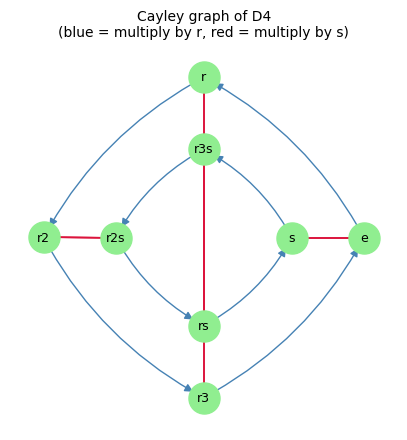

In [6]:
def dihedral_cayley_graph(n):
    elts, names, name_of, compose = make_dihedral_group(n)
    r, s = (1, 0), (0, 1)
    G = nx.MultiDiGraph()
    G.add_nodes_from(names)
    for e in elts:
        G.add_edge(name_of[e], name_of[compose(e, r)], gen="r")
        G.add_edge(name_of[e], name_of[compose(e, s)], gen="s")

    def orbit(start):
        order, cur = [start], start
        for _ in range(n - 1):
            cur = compose(cur, r)
            order.append(cur)
        return order

    pos = {}
    for i, e in enumerate(orbit((0, 0))):     # the n rotations, in order
        ang = 2 * np.pi * i / n
        pos[name_of[e]] = (np.cos(ang), np.sin(ang))
    for i, e in enumerate(orbit((0, 1))):     # the n reflections, in order
        ang = 2 * np.pi * i / n
        pos[name_of[e]] = (0.55 * np.cos(ang), 0.55 * np.sin(ang))
    return G, pos

def draw_cayley(G, pos, ax, title):
    if isinstance(G, nx.MultiDiGraph):
        edge_r = [(u, v) for u, v, d in G.edges(data=True) if d["gen"] == "r"]
        edge_s = [(u, v) for u, v, d in G.edges(data=True) if d["gen"] == "s"]
        nx.draw_networkx_nodes(G, pos, node_color="lightgreen", ax=ax, node_size=500)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
        nx.draw_networkx_edges(G, pos, edgelist=edge_r, edge_color="steelblue", ax=ax,
                                connectionstyle="arc3,rad=0.15", arrows=True, arrowsize=12)
        nx.draw_networkx_edges(G, pos, edgelist=edge_s, edge_color="crimson", ax=ax,
                                arrows=False, width=1.2)
    else:
        nx.draw(G, pos, with_labels=True, node_color="lightblue", ax=ax, arrows=True, node_size=500)
    ax.set_title(title, fontsize=10)
    ax.axis("equal"); ax.axis("off")

G_d4, pos_d4 = dihedral_cayley_graph(4)
fig, ax = plt.subplots(figsize=(5, 5))
draw_cayley(G_d4, pos_d4, ax, "Cayley graph of D4\n(blue = multiply by r, red = multiply by s)")
plt.show()


**Compare this to ℤ₆'s single loop.** Why two rings instead of one? Why does
every red edge (the reflection `s`) come as a matched pair of arrows instead
of a one-way arrow like the blue ones? (Hint: what is $s \circ s$?)


---
# 3. Same size, very different shape

ℤ₈ and D4 both have exactly 8 elements. Side by side:


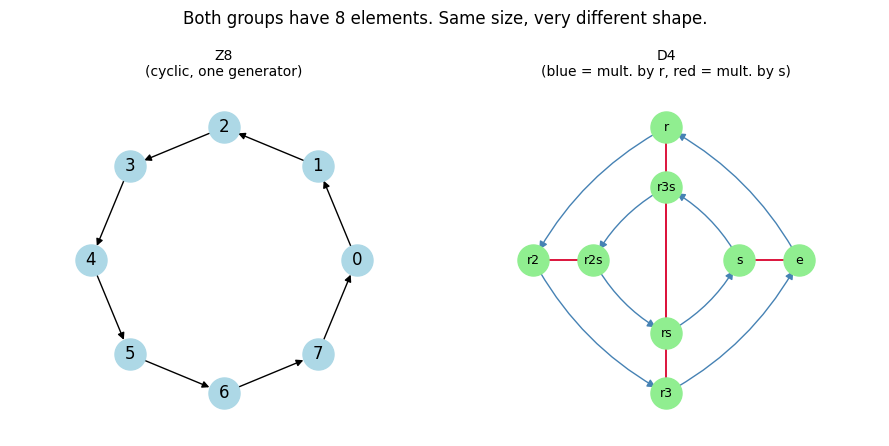

In [7]:
G_z8, pos_z8 = cyclic_cayley_graph(8, gen=1)
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
draw_cayley(G_z8, pos_z8, axes[0], "Z8\n(cyclic, one generator)")
draw_cayley(G_d4, pos_d4, axes[1], "D4\n(blue = mult. by r, red = mult. by s)")
fig.suptitle("Both groups have 8 elements. Same size, very different shape.")
fig.tight_layout()
plt.show()


If someone told you "there's really only one way to arrange 8 things into a
group," what would you show them from this notebook to prove otherwise?


---
# 4. Bonus: the quaternion group Q8 (optional)

Every group above has been either cyclic or dihedral. First, with tools you
already have: go back to Section 2's `make_dihedral_group` and
`dihedral_cayley_graph` and try `n = 3` and `n = 5` (triangle and pentagon
symmetries) — the code doesn't care, it was written to work for any `n`.

Now for something not usually covered in a first course on group theory: the
**quaternion group** $Q_8 = \{\pm 1, \pm i, \pm j, \pm k\}$, with
$i^2 = j^2 = k^2 = -1$ and $ij = k$, $jk = i$, $ki = j$ (and $ji = -k$, and so
on — multiplication does not commute here either). It also has exactly 8
elements, and like D4 it's non-abelian. Before running the cell: do you
expect its Cayley graph to look like D4's, or different again?


Q8 multiplication rules check out


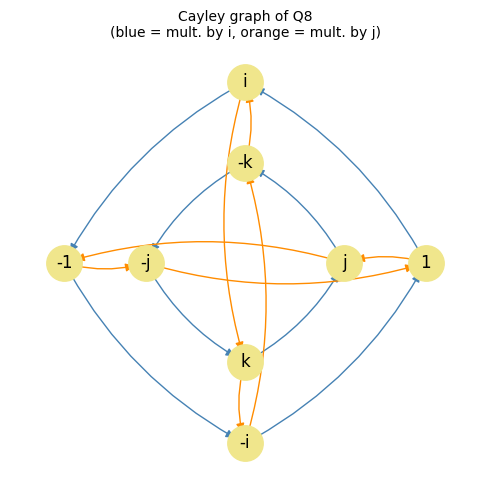

In [8]:
def quat_mul(p, q):
    a1, b1, c1, d1 = p
    a2, b2, c2, d2 = q
    return (a1*a2 - b1*b2 - c1*c2 - d1*d2,
            a1*b2 + b1*a2 + c1*d2 - d1*c2,
            a1*c2 - b1*d2 + c1*a2 + d1*b2,
            a1*d2 + b1*c2 - c1*b2 + d1*a2)

Q8 = {"1": (1,0,0,0), "-1": (-1,0,0,0), "i": (0,1,0,0), "-i": (0,-1,0,0),
      "j": (0,0,1,0), "-j": (0,0,-1,0), "k": (0,0,0,1), "-k": (0,0,0,-1)}
name_by_val = {v: k for k, v in Q8.items()}

def q_compose(n1, n2):
    return name_by_val[quat_mul(Q8[n1], Q8[n2])]

# spot-check against the defining relations before trusting the graph below
assert q_compose("i", "j") == "k"
assert q_compose("j", "i") == "-k"
assert q_compose("i", "i") == "-1"
print("Q8 multiplication rules check out")

def orbit(start, gen, k):
    order, cur = [start], start
    for _ in range(k - 1):
        cur = q_compose(cur, gen)
        order.append(cur)
    return order

outer, inner = orbit("1", "i", 4), orbit("j", "i", 4)
pos = {}
for idx, nm in enumerate(outer):
    ang = 2 * np.pi * idx / 4
    pos[nm] = (np.cos(ang), np.sin(ang))
for idx, nm in enumerate(inner):
    ang = 2 * np.pi * idx / 4
    pos[nm] = (0.55 * np.cos(ang), 0.55 * np.sin(ang))

G_q8 = nx.MultiDiGraph()
G_q8.add_nodes_from(Q8)
for nm in Q8:
    G_q8.add_edge(nm, q_compose(nm, "i"), gen="i")
    G_q8.add_edge(nm, q_compose(nm, "j"), gen="j")

fig, ax = plt.subplots(figsize=(5, 5))
edge_i = [(u, v) for u, v, d in G_q8.edges(data=True) if d["gen"] == "i"]
edge_j = [(u, v) for u, v, d in G_q8.edges(data=True) if d["gen"] == "j"]
nx.draw_networkx_nodes(G_q8, pos, node_color="khaki", ax=ax, node_size=650)
nx.draw_networkx_labels(G_q8, pos, ax=ax)
nx.draw_networkx_edges(G_q8, pos, edgelist=edge_i, edge_color="steelblue", ax=ax,
                        connectionstyle="arc3,rad=0.15", arrows=True, arrowsize=12)
nx.draw_networkx_edges(G_q8, pos, edgelist=edge_j, edge_color="darkorange", ax=ax,
                        connectionstyle="arc3,rad=0.15", arrows=True, arrowsize=12)
ax.set_title("Cayley graph of Q8\n(blue = mult. by i, orange = mult. by j)", fontsize=10)
ax.axis("equal"); ax.axis("off")
plt.tight_layout()
plt.show()


It's a fair question whether $Q_8$'s picture is "really" different from D4's
or just a relabeling. It isn't a relabeling: one way to see this later is
that *every* subgroup of $Q_8$ is normal, which is false for D4. Filing that
away is enough for now — proving it takes tools beyond this notebook.


---
# 5. Summary

- A group's Cayley graph — one node per element, one edge per generator —
  can look completely different from another group of the *same order*.
  ℤ₈'s is a single loop; D4's is two rings of 4 linked by a twist; Q8's is
  shaped like D4's yet is a genuinely different group.
- Non-abelian doesn't mean "all alike": D4 and Q8 are both non-abelian order-8
  groups, but they differ in structural ways (e.g. normality of every
  subgroup) that go beyond what a Cayley graph picture alone reveals.
- None of this required proving anything by hand — the code discovered the
  group table, checked closure, and drew the structure, which is often the
  fastest way to build the right intuition *before* proving something.


---
# 6. Exercises

1. **Generalize.** Adapt the ℤₙ code to plot the Cayley graph for a second
   generator, e.g. `gen=2` in `Z6`. When is the resulting graph connected,
   and when does it split into several disjoint loops?
2. **D3, D5, D7.** Use `dihedral_cayley_graph` with `n = 3, 5, 7` and compare
   the pictures to D4's. What stays the same about the shape as `n` grows?
   What changes?
3. **Count the twist.** In D4's Cayley graph, the red (`s`) edges connect the
   outer ring to the inner ring, but not straight across. Work out, for
   general `n`, exactly how many positions the connection is "twisted" by,
   and relate it to the relation $srs = r^{-1}$.
4. **A cube's symmetries.** A cube has 24 rotational symmetries (ignoring
   reflections). Without writing any code, can you name a smaller group
   you've already built above that you'd expect to find *inside* that group
   of 24? (No single right answer is expected — the point is the reasoning.)


---
## License

This notebook is released under the [Creative Commons Attribution 4.0
International License (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/). You are free to copy, adapt,
and redistribute it, including for commercial purposes, provided you give
appropriate credit.

Suggested attribution: *"Symmetry Groups and Cayley Graphs" by [Eduardo Dueñez](https://supernumero.us/about),
licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*
